In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv("/Users/tanayreddyvaddula/Desktop/datasets/pca.csv")
df

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,93,34.0,66.0,140.0,56.0,7,130.0,51.0,18.0,120,151.0,251.0,114.0,62.0,5.0,29.0,201.0,207,car
841,93,39.0,87.0,183.0,64.0,8,169.0,40.0,20.0,134,200.0,422.0,149.0,72.0,7.0,25.0,188.0,195,car
842,89,46.0,84.0,163.0,66.0,11,159.0,43.0,20.0,159,173.0,368.0,176.0,72.0,1.0,20.0,186.0,197,van
843,106,54.0,101.0,222.0,67.0,12,222.0,30.0,25.0,173,228.0,721.0,200.0,70.0,3.0,4.0,187.0,201,car


In [5]:
df["class"].unique()

<StringArray>
['van', 'car', 'bus']
Length: 3, dtype: str

In [6]:
df.isnull().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

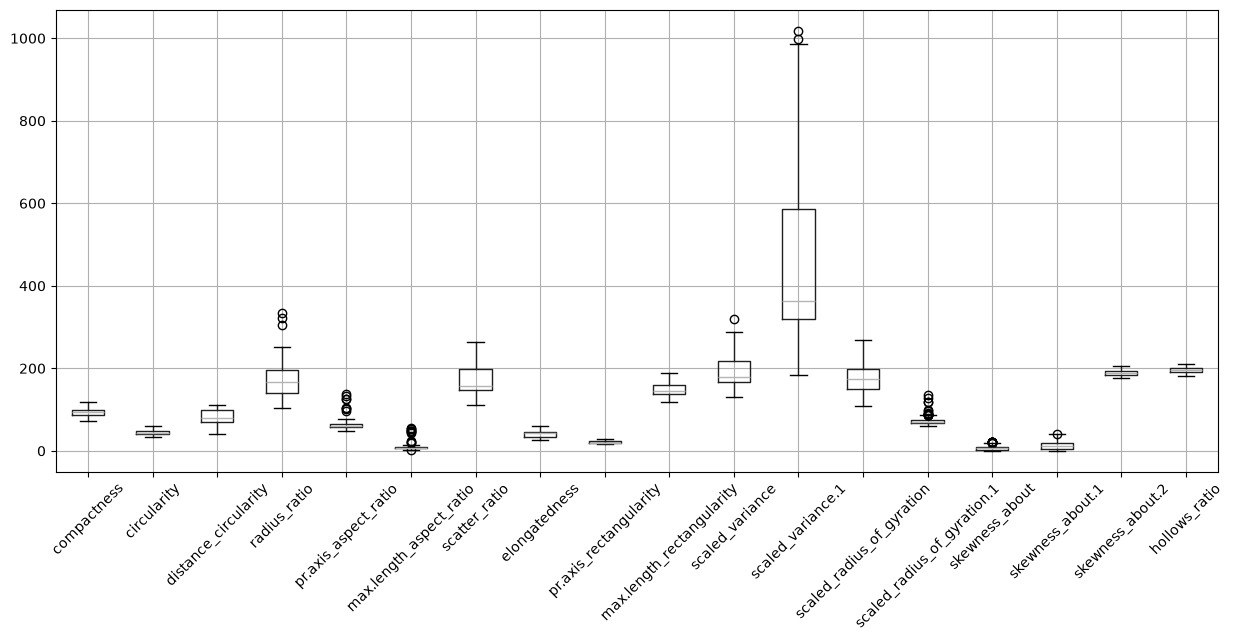

In [13]:
nums = ["skewness_about.1","skewness_about.2","skewness_about","scaled_radius_of_gyration.1","scaled_radius_of_gyration","scaled_variance.1","scaled_variance","pr.axis_rectangularity",
       "elongatedness","scatter_ratio","pr.axis_aspect_ratio","radius_ratio","distance_circularity","circularity"]
plt.figure(figsize=(15,6))
df.drop("class",axis=1).boxplot(rot=45)
plt.show()

In [10]:
for i in nums:
    df[i] = df[i].fillna(df[i].median())

In [11]:
df.isnull().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [14]:
sc = StandardScaler()
x = df.drop("class",axis=1)
y = df["class"]

In [17]:
x_scaled = sc.fit_transform(x)
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

In [21]:
explained_variance = pca.explained_variance_ratio_
explained_variance_df = pd.DataFrame({
    'Principal Components':range(1,len(explained_variance)+1),
    'Explained Variance':explained_variance,
    'Explained Variance (%)':explained_variance*100
})

In [22]:
explained_variance_df

,Principal Components,Explained Variance,Explained Variance (%)
0,1,0.521579,52.157856
1,2,0.167378,16.737780
2,3,0.105705,10.570476
3,4,0.065449,6.544908
4,5,0.050951,5.095080
5,6,0.030003,3.000257
6,7,0.019938,1.993839
7,8,0.012333,1.233280
8,9,0.008912,0.891156
9,10,0.005102,0.510236


In [25]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance_df = pd.DataFrame({
    'Principal Components':range(1,len(explained_variance)+1),
    'Cumulative Variance':cumulative_variance,
    'Cumulative Variance (%)':cumulative_variance*100
})

In [26]:
cumulative_variance_df

,Principal Components,Cumulative Variance,Cumulative Variance (%)
0,1,0.521579,52.157856
1,2,0.688956,68.895636
2,3,0.794661,79.466111
3,4,0.860110,86.011020
4,5,0.911061,91.106100
5,6,0.941064,94.106356
6,7,0.961002,96.100196
7,8,0.973335,97.333476
8,9,0.982246,98.224632
9,10,0.987349,98.734868


In [28]:
n_components_95 = np.argmax(cumulative_variance>=0.95)+1
print(n_components_95)

7


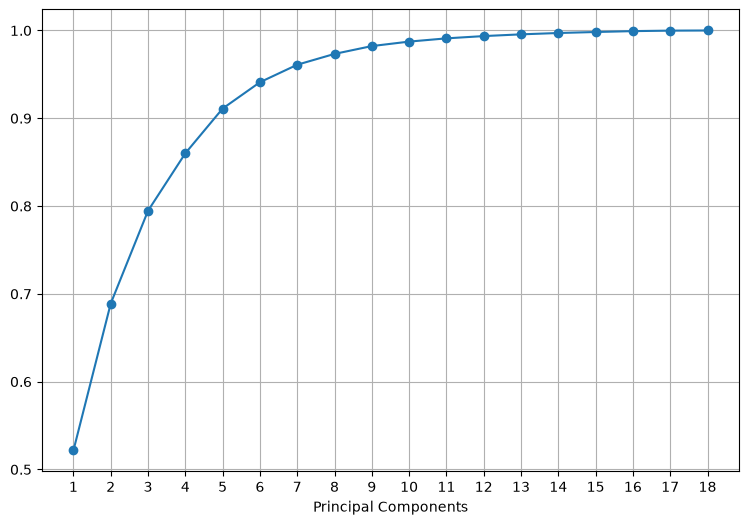

In [30]:
plt.figure(figsize=(9,6))
plt.plot(range(1,len(cumulative_variance)+1),
        cumulative_variance,
        marker='o')
plt.xlabel("Principal Components")
plt.xticks(range(1,len(cumulative_variance)+1))
plt.grid(True)
plt.show()

In [31]:
pca_reduced = PCA(n_components =n_components_95)
x_reduced = pca_reduced.fit_transform(x_scaled)
print(x_scaled.shape)
print(x_reduced.shape)

(845, 18)
(845, 7)


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df["class"])

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x_reduced,y,random_state = 42,test_size = 0.2,stratify = y)
nb = GaussianNB()
svm_rbf = SVC(kernel = 'rbf',
              C = 1,
             gamma = 'scale')
lr = LogisticRegression()


In [39]:
nb.fit(x_train,y_train)
svm_rbf.fit(x_train,y_train)
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [42]:
nb_pred = nb.predict(x_test)
svm_pred = svm_rbf.predict(x_test)
lr_pred = lr.predict(x_test)


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Algorithm": ["Naive Bayes", "SVM (RBF)", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred, average="weighted"),
        precision_score(y_test, svm_pred, average="weighted"),
        precision_score(y_test, lr_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, nb_pred, average="weighted"),
        recall_score(y_test, svm_pred, average="weighted"),
        recall_score(y_test, lr_pred, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted"),
        f1_score(y_test, lr_pred, average="weighted")
    ]
})

results

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.704142,0.734517,0.704142,0.683825
1,SVM (RBF),0.899408,0.900742,0.899408,0.899151
2,Logistic Regression,0.763314,0.764639,0.763314,0.763921
